## Numerical Methods In Finance | fall 2024


### *Test*

#### _Makhova Anastasia_ 

Please send your file to **vantipov@nes.ru** with topic **"NMF 2024 - Test - Surname"**. Please also rename your file as **"Surname_NMF2024_Test.ipynb"** before sending. If your answer contains many files, please add them to archive (e.g. use zip format) with the same name as the main file.

If you have any questions feel free to ask in Telegram in the group chat.

### 1. Salvaging a linear correlation matrix

You are given a correlation matrix estimated by the historical returns on the following equity stocks **SBER, YDEX, T, MGNT**:

$$\text{C} = \begin{pmatrix} 1 & 0.78 & 0.8 & 0.45 \\ 0.78 & 1 & 0.75 & 0.9 \\ 0.8 & 0.75 & 1 & 0.85 \\ 0.45 & 0.9 & 0.85 & 1 \end{pmatrix}$$

Unfortunately, this correlation matrix is not positive-semidefinite.

On the seminar you faced with two algorithms, based on **hypersphere** and **spectral** decompositions, providing the way on how to adjust a correlation matrix to make it positive-semidefinite. Each of these algorithms have their own pros and cons. Your task is to combine these approaches to construct the new and the best one.

Implement the following algorithm:

1. Apply a **spectral** decomposition algorithm, that is construct a symmetrix positive-definite matrix $\widetilde{\text{C}} = \text{B} \cdot \text{B}^T. $

2. Apply Cholesky decomposition to matrix $\widetilde{\text{C}} = \text{L} \cdot \text{L}^{T}$. 

3. Use matrix $\text{L}$ as an initial guess for the **hyphersphere** decomposition $\widetilde{\text{C}} = \text{B}' \cdot \text{B}'^T$ with reduced number of $\frac{n(n-1)}{2}$ angles, constructed with an optimization procedure.

Your answer should contatin the resulting matrix $\widetilde{\text{C}}$ and the $L_2$ norm between it and the original one. Does this combo-algorithm performs better than each of the algorithms separately?

----------

In [1]:
import numpy as np
import copy
import scipy 
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt

$$\text{C} = \begin{pmatrix} 1 & 0.78 & 0.8 & 0.45 \\ 0.78 & 1 & 0.75 & 0.9 \\ 0.8 & 0.75 & 1 & 0.85 \\ 0.45 & 0.9 & 0.85 & 1 \end{pmatrix}$$

In [2]:
# Set a correlation matrix
C = np.array([[1, 0.78, 0.8, 0.45], [0.78, 1, 0.75, 0.9], [0.8, 0.75, 1, 0.85], [0.45, 0.9, 0.85, 1]])
C

array([[1.  , 0.78, 0.8 , 0.45],
       [0.78, 1.  , 0.75, 0.9 ],
       [0.8 , 0.75, 1.  , 0.85],
       [0.45, 0.9 , 0.85, 1.  ]])

##### 1. Spectral decomosition

> 1. Apply a **spectral** decomposition algorithm, that is construct a symmetrix positive-definite matrix $\widetilde{\text{C}} = \text{B} \cdot \text{B}^T. $


$\widetilde{\text{C}} = \text{B} \cdot \text{B}^T. $



Any symmetric matrix $\text{C}$ can be decomposed as 

$$\text{C} = \text{Q} \cdot \Lambda \cdot \text{Q}^{-1}, \qquad \Lambda = \text{diag}(\lambda_i), \qquad \text{Q}^{T} = \text{Q}^{-1}.$$

The values $\lambda_i$ are eigen values of $\text{C}$ and columns of $\text{Q}$ are (orthogonal) eigen vectors of $\text{C}$.
The matrix $\text{C}$ turns out to be positive-semidefinite if and only if 

$$\lambda_i \geq 0.$$
Define a diagonal matrix $\Lambda' = \text{diag}(\lambda_i')$ such that 

$$\lambda_i' = \begin{cases} \lambda_i \quad : \quad \lambda_i \geq 0, \\ 0 \quad : \quad \lambda_i < 0.\end{cases}$$
Hence, the target matrix $\text{C}$ is not positive-semidefinite if at least one of $\lambda_i'$ is zero. 
Let $\text{T} = \text{diag}(t_i)$ be a diagonal scaling matrix with 

$$t_i = \left( \sum_{m} q^2_{im} \lambda_m' \right)^{-1}.$$
Let

$$\text{B} := \sqrt{\text{T}} \cdot \text{Q} \cdot \sqrt{\Lambda'}.$$

Then 

$$\widetilde{\text{C}} := \text{B} \cdot \text{B}^T = \sqrt{\text{T}} \cdot \text{Q} \cdot \sqrt{\Lambda'} \cdot \sqrt{\Lambda'} \cdot \text{Q}^T \cdot  \sqrt{\text{T}} = \sqrt{\text{T}} \cdot \text{Q} \cdot \Lambda' \cdot \text{Q}^T \cdot  \sqrt{\text{T}}$$

is now both positive-semidefinite and has unit diagonal elements. 

In [3]:
L, Q = scipy.linalg.schur(C)

print("Diagonal matrix L from Schur decomposition: \n {} \n".format(L))
print("Unitary matrix Q from Schur decomposition: \n {} \n".format(Q))

Diagonal matrix L from Schur decomposition: 
 [[ 3.27322866e+00  8.42918197e-16  3.61866766e-16 -9.03161771e-17]
 [ 0.00000000e+00  5.57483584e-01  3.40005832e-16 -1.66336331e-16]
 [ 0.00000000e+00  0.00000000e+00 -7.76167007e-02 -4.21671863e-18]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  2.46904452e-01]] 

Unitary matrix Q from Schur decomposition: 
 [[-0.46038487 -0.75713862 -0.45229967 -0.10105386]
 [-0.52454466  0.10684936  0.50613849 -0.67620999]
 [-0.51943617 -0.04691529  0.44454689  0.72826031]
 [-0.49303625  0.64274666 -0.58448857  0.04653057]] 



In [4]:
def truncate_negative_eigen_values(L: np.ndarray):
    L_ = copy.deepcopy(L)
    L_[np.diag_indices_from(L_)] = np.maximum(np.diag(L_), 0)
    return L_

In [5]:
L_ = truncate_negative_eigen_values(L)
print("Diagonal matrix L from Schur decomposition: \n {} \n".format(L))
print("Truncated matrix L_: \n {} \n".format(L_))

Diagonal matrix L from Schur decomposition: 
 [[ 3.27322866e+00  8.42918197e-16  3.61866766e-16 -9.03161771e-17]
 [ 0.00000000e+00  5.57483584e-01  3.40005832e-16 -1.66336331e-16]
 [ 0.00000000e+00  0.00000000e+00 -7.76167007e-02 -4.21671863e-18]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  2.46904452e-01]] 

Truncated matrix L_: 
 [[ 3.27322866e+00  8.42918197e-16  3.61866766e-16 -9.03161771e-17]
 [ 0.00000000e+00  5.57483584e-01  3.40005832e-16 -1.66336331e-16]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -4.21671863e-18]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  2.46904452e-01]] 



In [6]:
def scaling_matrix(Q: np.ndarray, L_: np.ndarray):
    return np.diag(1 / np.sum(Q * Q * np.diag(L_), axis=1))

In [7]:
T = scaling_matrix(Q, L_)
print("Scaling matrix T: \n {} \n".format(T))

Scaling matrix T: 
 [[0.98436975 0.         0.         0.        ]
 [0.         0.9805041  0.         0.        ]
 [0.         0.         0.98489296 0.        ]
 [0.         0.         0.         0.97416898]] 



In [8]:
def correlation_matrix(Q: np.ndarray, T: np.ndarray, L_: np.ndarray):
    B = np.sqrt(T) @ Q @ np.sqrt(np.abs(L_))
    return B @ B.T

In [9]:
C_approx_spec_decomp = correlation_matrix(Q, T, L_)

In [10]:
print("Initial symmetric matrix C: \n {} \n".format(C))
print("Positive-definite matrix constructed via spectral decomposition: \n {} \n".format(C_approx_spec_decomp))

Initial symmetric matrix C: 
 [[1.   0.78 0.8  0.45]
 [0.78 1.   0.75 0.9 ]
 [0.8  0.75 1.   0.85]
 [0.45 0.9  0.85 1.  ]] 

Positive-definite matrix constructed via spectral decomposition: 
 [[1.00000002 0.74884293 0.77233864 0.46075865]
 [0.74884293 1.         0.7541838  0.85715725]
 [0.77233864 0.7541838  1.         0.8128346 ]
 [0.46075865 0.85715725 0.8128346  0.99999999]] 



##### 2.Cholesky

>2. Apply Cholesky decomposition to matrix $\widetilde{\text{C}} = \text{L} \cdot \text{L}^{T}$. 



$A$ - symetric positive-definite matrix

Cholesky decomposition:
$$ A=LL^{T} $$
where L — lower triangle matrix with positive diagonal elements 

In [11]:
L = scipy.linalg.cholesky(C_approx_spec_decomp, lower=True)

In [12]:
print("Reconstructed matrix via Cholesky decomposition: \n {} \n".format(L @ L.T.conj()))

Reconstructed matrix via Cholesky decomposition: 
 [[1.00000002 0.74884293 0.77233864 0.46075865]
 [0.74884293 1.         0.7541838  0.85715725]
 [0.77233864 0.7541838  1.         0.8128346 ]
 [0.46075865 0.85715725 0.8128346  0.99999999]] 



##### 3. Hypersphere decomposition

> 3. Use matrix $\text{L}$ as an initial guess for the **hyphersphere** decomposition $\widetilde{\text{C}} = \text{B}' \cdot \text{B}'^T$ with reduced number of $\frac{n(n-1)}{2}$ angles, constructed with an optimization procedure.

$$\widetilde{\text{C}} = \text{B}' \cdot \text{B}'^{T}$$

$$b_{ij} = \cos(\theta_{ij}) \cdot \prod_{k=1}^{j-1} \sin(\theta_{ik}), \qquad j=1,\dots,n-1,$$
$$b_{ij} = \prod_{k=1}^{j-1} \sin(\theta_{ik}), \qquad j = n.$$

Initial guess: $\widetilde{\text{C}} = \text{L} \cdot \text{L}^{T}$

$$l_{ij} = \cos(\theta_{ij}) \cdot \prod_{k=1}^{j-1} \sin(\theta_{ik}), \qquad j=1,\dots,i $$

$$ \Rightarrow \quad \theta_{ij} = \begin{cases}
\text{arccos}(\frac{l_{ij}}{\prod_{k=1}^{j-1} \sin(\theta_{ik})}) & j = 2, \cdots, n-1\\
\text{arccos}(l_{ij}) & j = 1
\end{cases}$$

If $\prod_{k=1}^{j-1} \sin(\theta_{ik}) = 0$ we can define any $\theta_{ij}$, e.g. $\theta_{ik} = 0$ 




+  All diagonal elements of $\widetilde{\text{C}}$ are equal to $1$ and all other are in $[-1, 1]$ range.  
+ $\widetilde{\text{C}}$ is by construction positive definite and symmetric. 

Optimisation procedure 

$$\varepsilon( \theta) = \| \widetilde{\text{C}} - \text{C}\|_2 = \sum_{i,j} (\widetilde{c_{ij}}(\theta) - c_{ij})^2 \longrightarrow 0 \qquad \text{w.r.t.} \quad \theta.$$

In [13]:
def B(theta: np.ndarray):
    cosine_B = np.cos(theta)
    cosine_B_shifted = np.c_[cosine_B, np.ones(cosine_B.shape[0])]
    sin_B = np.sin(theta)
    sin_B_shifted = np.c_[np.ones(sin_B.shape[0]), sin_B]
    sin_B_shifted_cumprod = np.cumprod(sin_B_shifted, axis=-1)
    return cosine_B_shifted * sin_B_shifted_cumprod

In [14]:
def reshape_theta_to_appropriate_size(theta: np.ndarray, n: int):
    theta_size = theta.shape[0]
    rows_dim = int(n)
    cols_dim = int(theta_size / rows_dim)
    return theta.reshape(rows_dim, cols_dim)

In [15]:
def l2_norm(theta: np.ndarray, C: np.ndarray):
    theta = reshape_theta_to_appropriate_size(theta=theta, n=C.shape[0])
    B_ = B(theta)
    C_approx = B_ @ B_.T
    return np.linalg.norm(C_approx - C, ord = 'fro')

In [16]:
def get_theta(L: np.ndarray):
    theta = np.zeros_like(L)
    n = np.shape(L)[0]

    for i in range(n):
        for j in range(i+1):
            if j == 0:
                #have to clip L even if |l_ij|<=1 for all i, j
                theta[i,j] = np.arccos(np.clip(L[i, j], -1.0, 1.0))
                continue
            else:
                prod = np.prod([np.sin(theta[i, k]) for k in range(j)])
                if prod == 0:
                    theta[i, j] = 0  # Handle zero-product case
                else:
                    value = L[i, j] / prod
                    theta[i, j] = np.arccos(np.clip(value, -1.0, 1.0))

    return theta.ravel()


In [17]:
L

array([[1.00000001e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.48842925e-01, 6.62747518e-01, 0.00000000e+00, 0.00000000e+00],
       [7.72338634e-01, 2.65294813e-01, 5.77158293e-01, 0.00000000e+00],
       [4.60758650e-01, 7.72724721e-01, 4.36575262e-01, 1.05367121e-08]])

In [18]:
theta = get_theta(L)
theta

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       7.24481850e-01, 3.96557473e-05, 0.00000000e+00, 0.00000000e+00,
       6.88281706e-01, 1.13994077e+00, 8.23454104e-05, 0.00000000e+00,
       1.09194653e+00, 5.14272621e-01, 2.63920275e-04, 1.57070488e+00])

In [19]:
# Optimization
res = minimize(fun=l2_norm, x0 =theta, args=C, method="BFGS")

In [20]:
print("Optimal θ_opt: \n {} \n".format(res.x))
print("L2 norm minimum at given θ_opt: \n {} \n".format(res.fun))

Optimal θ_opt: 
 [ 3.84354441e-03  4.19207758e-06  0.00000000e+00  0.00000000e+00
  7.17476057e-01  2.10909294e-02 -2.24142774e-06  0.00000000e+00
  6.78743773e-01  1.12129553e+00  2.16596798e-06  1.51821103e-08
  1.07601062e+00  5.11861069e-01 -5.91704895e-07  1.57070487e+00] 

L2 norm minimum at given θ_opt: 
 0.09050742853944055 



In [21]:
#Reshape optimal theta
theta_opt = res.x
theta_opt_reshaped = reshape_theta_to_appropriate_size(theta=theta_opt, n=4)
theta_opt_reshaped

array([[ 3.84354441e-03,  4.19207758e-06,  0.00000000e+00,
         0.00000000e+00],
       [ 7.17476057e-01,  2.10909294e-02, -2.24142774e-06,
         0.00000000e+00],
       [ 6.78743773e-01,  1.12129553e+00,  2.16596798e-06,
         1.51821103e-08],
       [ 1.07601062e+00,  5.11861069e-01, -5.91704895e-07,
         1.57070487e+00]])

In [22]:
# Build positive-definite matrix with obtained optimal theta
C_approx_opt = B(theta_opt_reshaped) @ B(theta_opt_reshaped).T

In [23]:
print("Initial symmetric matrix C: \n {} \n".format(C))
print("Positive-semidefinite matrix constructed via angular decomposition of lower triangular form: \n {} \n".format(C_approx_opt))

Initial symmetric matrix C: 
 [[1.   0.78 0.8  0.45]
 [0.78 1.   0.75 0.9 ]
 [0.8  0.75 1.   0.85]
 [0.45 0.9  0.85 1.  ]] 

Positive-semidefinite matrix constructed via angular decomposition of lower triangular form: 
 [[1.         0.75598852 0.77940477 0.47778862]
 [0.75598852 1.         0.77363043 0.86811607]
 [0.77940477 0.77363043 1.         0.82265237]
 [0.47778862 0.86811607 0.82265237 1.        ]] 



##### Comparison of models

In [24]:
#hyphersphere decomposition
theta = np.random.rand(8)
res = minimize(fun=l2_norm, x0 =theta, args=C, method="BFGS")
theta_opt = res.x
theta_opt_reshaped = reshape_theta_to_appropriate_size(theta=theta_opt, n=4)
C_approx_hypher = B(theta_opt_reshaped) @ B(theta_opt_reshaped).T


In [25]:
# Comparison of eigen martixes 
print("Initial symmetric matrix C: \n {} \n".format(C))
print("Positive-semidefinite matrix constructed via spectral decomposition: \n {} \n".format(C_approx_spec_decomp))
print("Positive-semidefinite matrix constructed via hyphersphere decomposition with optimization: \n {} \n".format(C_approx_hypher))
print("Positive-semidefinite matrix constructed via angular decomposition of lower triangular form: \n {} \n".format(C_approx_opt))

Initial symmetric matrix C: 
 [[1.   0.78 0.8  0.45]
 [0.78 1.   0.75 0.9 ]
 [0.8  0.75 1.   0.85]
 [0.45 0.9  0.85 1.  ]] 

Positive-semidefinite matrix constructed via spectral decomposition: 
 [[1.00000002 0.74884293 0.77233864 0.46075865]
 [0.74884293 1.         0.7541838  0.85715725]
 [0.77233864 0.7541838  1.         0.8128346 ]
 [0.46075865 0.85715725 0.8128346  0.99999999]] 

Positive-semidefinite matrix constructed via hyphersphere decomposition with optimization: 
 [[1.         0.75598886 0.77940439 0.47778856]
 [0.75598886 1.         0.77363052 0.86811569]
 [0.77940439 0.77363052 1.         0.82265282]
 [0.47778856 0.86811569 0.82265282 1.        ]] 

Positive-semidefinite matrix constructed via angular decomposition of lower triangular form: 
 [[1.         0.75598852 0.77940477 0.47778862]
 [0.75598852 1.         0.77363043 0.86811607]
 [0.77940477 0.77363043 1.         0.82265237]
 [0.47778862 0.86811607 0.82265237 1.        ]] 



In [26]:
# Comparison of eigen values 
print("Eigen values of initial symmetric matrix C: \n {} \n".format(np.linalg.eig(C).eigenvalues))
print("Eigen values of positive-definite matrix constructed via spectral decomposition: \n {} \n".format(np.linalg.eig(C_approx_spec_decomp).eigenvalues))
print("Eigen values of positive-definite matrix constructed via hyphersphere decomposition with optimiszation: \n {} \n".format(np.linalg.eig(C_approx_hypher).eigenvalues))
print("Eigen values of positive-definite matrix constructed via angular decomposition of lower triangular form: \n {} \n".format(np.linalg.eig(C_approx_opt).eigenvalues))

Eigen values of initial symmetric matrix C: 
 [ 3.27322866  0.55748358 -0.0776167   0.24690445] 

Eigen values of positive-definite matrix constructed via spectral decomposition: 
 [3.21094011e+00 5.46388473e-01 6.55146674e-17 2.42671418e-01] 

Eigen values of positive-definite matrix constructed via hyphersphere decomposition with optimiszation: 
 [3.24678957e+00 5.29922560e-01 3.68496525e-16 2.23287867e-01] 

Eigen values of positive-definite matrix constructed via angular decomposition of lower triangular form: 
 [3.24678954e+00 5.29922659e-01 2.93889742e-13 2.23287803e-01] 



In [27]:
# Comparison of L2 norms
print("L2 norm of difference of initial symmetric matrix and positive-definite matrix constructed via spectral decomposition: \n {} \n".format(np.linalg.norm(C_approx_spec_decomp - C, ord = 'fro')))
print("L2 norm of difference of initial symmetric matrix and positive-definite matrix constructed via hyphersphere decomposition with optimiszation: \n {} \n".format(np.linalg.norm(C_approx_hypher - C, ord = 'fro')))
print("L2 norm of difference of initial symmetric matrix and positive-definite matrix constructed via angular decomposition of lower triangular form: \n {} \n".format(np.linalg.norm(C_approx_opt - C, ord = 'fro')))


L2 norm of difference of initial symmetric matrix and positive-definite matrix constructed via spectral decomposition: 
 0.10085569089004194 

L2 norm of difference of initial symmetric matrix and positive-definite matrix constructed via hyphersphere decomposition with optimiszation: 
 0.09050742854596985 

L2 norm of difference of initial symmetric matrix and positive-definite matrix constructed via angular decomposition of lower triangular form: 
 0.09050742853944055 



--------

---------

### 2. Monte-Carlo integration

Having constructed the positive-semidefintie correlation matrix, you need to use it to price a basket option on **SBER** and **MGNT**.

The payoff of your option at expiration $T$ is 

$$\text{Payoff}(S^{SBER}_T, S^{MGNT}_T) = \left(\frac{1}{2} \left(\frac{S^{SBER}_T}{S^{SBER}_0} + \frac{S^{MGNT}_T}{S^{MGNT}_0}\right) - 100\% \right)_{+}.$$

Assume that each stock evolves as a geometric Brownian motion:

$$S^{SBER}_T = S^{SBER}_0 e^{(r - (\sigma^{SBER})^2/2)T + \sigma^{SBER} W^{SBER}_T}, \quad S^{MGNT}_T = S^{MGNT}_0 e^{(r - (\sigma^{MGNT})^2/2)T + \sigma^{MGNT} W^{MGNT}_T},$$

where $W^{SBER}_T$ and $W^{MGNT}_T$ are Brownian motions correlated with $\rho^{SBER, MGNT}$. 

The price of the option can be expressed as the following expectation

$$P = e^{-rT} \cdot \mathbb{E}^{\mathbb{Q}} [\text{Payoff}(S^{SBER}_T, S^{MGNT}_T)],$$

wich can be evaluated using Monte-Carlo algorithm.

You may assume that risk-free interest rate $r = 21\%$, the initial stock prices are $S^{SBER}_0 = 230$, $S^{MGNT}_0 = 4300$ and the volatilities are $\sigma^{SBER}_0 = 30\%$, $\sigma^{MGNT}_0 = 40\%$. The maturity of the option $T$ is equal to on year.

Your answer should contatin the plot of the price $P$ of the option as a function on number of Monte-Carlo siulamations $N$. Does your algorithm converges? What is the speed of the convergence as a function of $N$? 

---------

In [28]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-light.mplstyle')
%matplotlib inline

In [29]:
r = 0.21
S0_SBER = 230
S0_MGNT = 4300

sigma0_SBER = 0.3
sigma0_MGNT = 0.4
T = 1

random_seed = 42

In [30]:
corr_matrix = C_approx_opt[[0, -1], :][:, [0, -1]]

In [31]:
def cholesky_decomposition(x: np.ndarray):
    return np.linalg.cholesky(x)

In [32]:
def sample_independent_uniform_variates(n_sample: int, size: int = 1, random_seed: int = 42):
    np.random.seed(random_seed)
    return np.random.rand(n_sample, size)

In [33]:
def transform_uniform_to_gaussian(uniform_sample: np.ndarray):
    return norm.ppf(uniform_sample)

In [34]:
def generate_normal(n_sample: int, corr_matrix: np.ndarray):
    """
    standard gaussian random variables with copula 
    """
    size = corr_matrix.shape[0]
    sample_of_independent_uniform_variates = sample_independent_uniform_variates(n_sample=n_sample, size=size)
    sample_of_independent_standard_gaussian_variates = transform_uniform_to_gaussian(uniform_sample=sample_of_independent_uniform_variates)
    square_root_matrix = cholesky_decomposition(x=corr_matrix)
    sample_of_codependent_standard_gaussian_variates =  sample_of_independent_standard_gaussian_variates @ square_root_matrix.T
    return sample_of_codependent_standard_gaussian_variates


In [35]:
def generate_normal_np(n_sample: int, corr_matrix: np.ndarray, random_seed: int = 42):
    """
    standard gaussian random variables with np.random.normal
    """
    size = corr_matrix.shape[0]
    random = np.random.default_rng(random_seed)
    sample_of_independent_standard_gaussian_variates = random.normal(size=(n_sample, size))
    square_root_matrix = cholesky_decomposition(x=corr_matrix)
    sample_of_codependent_standard_gaussian_variates =  sample_of_independent_standard_gaussian_variates @ square_root_matrix.T
    return sample_of_codependent_standard_gaussian_variates

In [36]:
n_sample = 1000

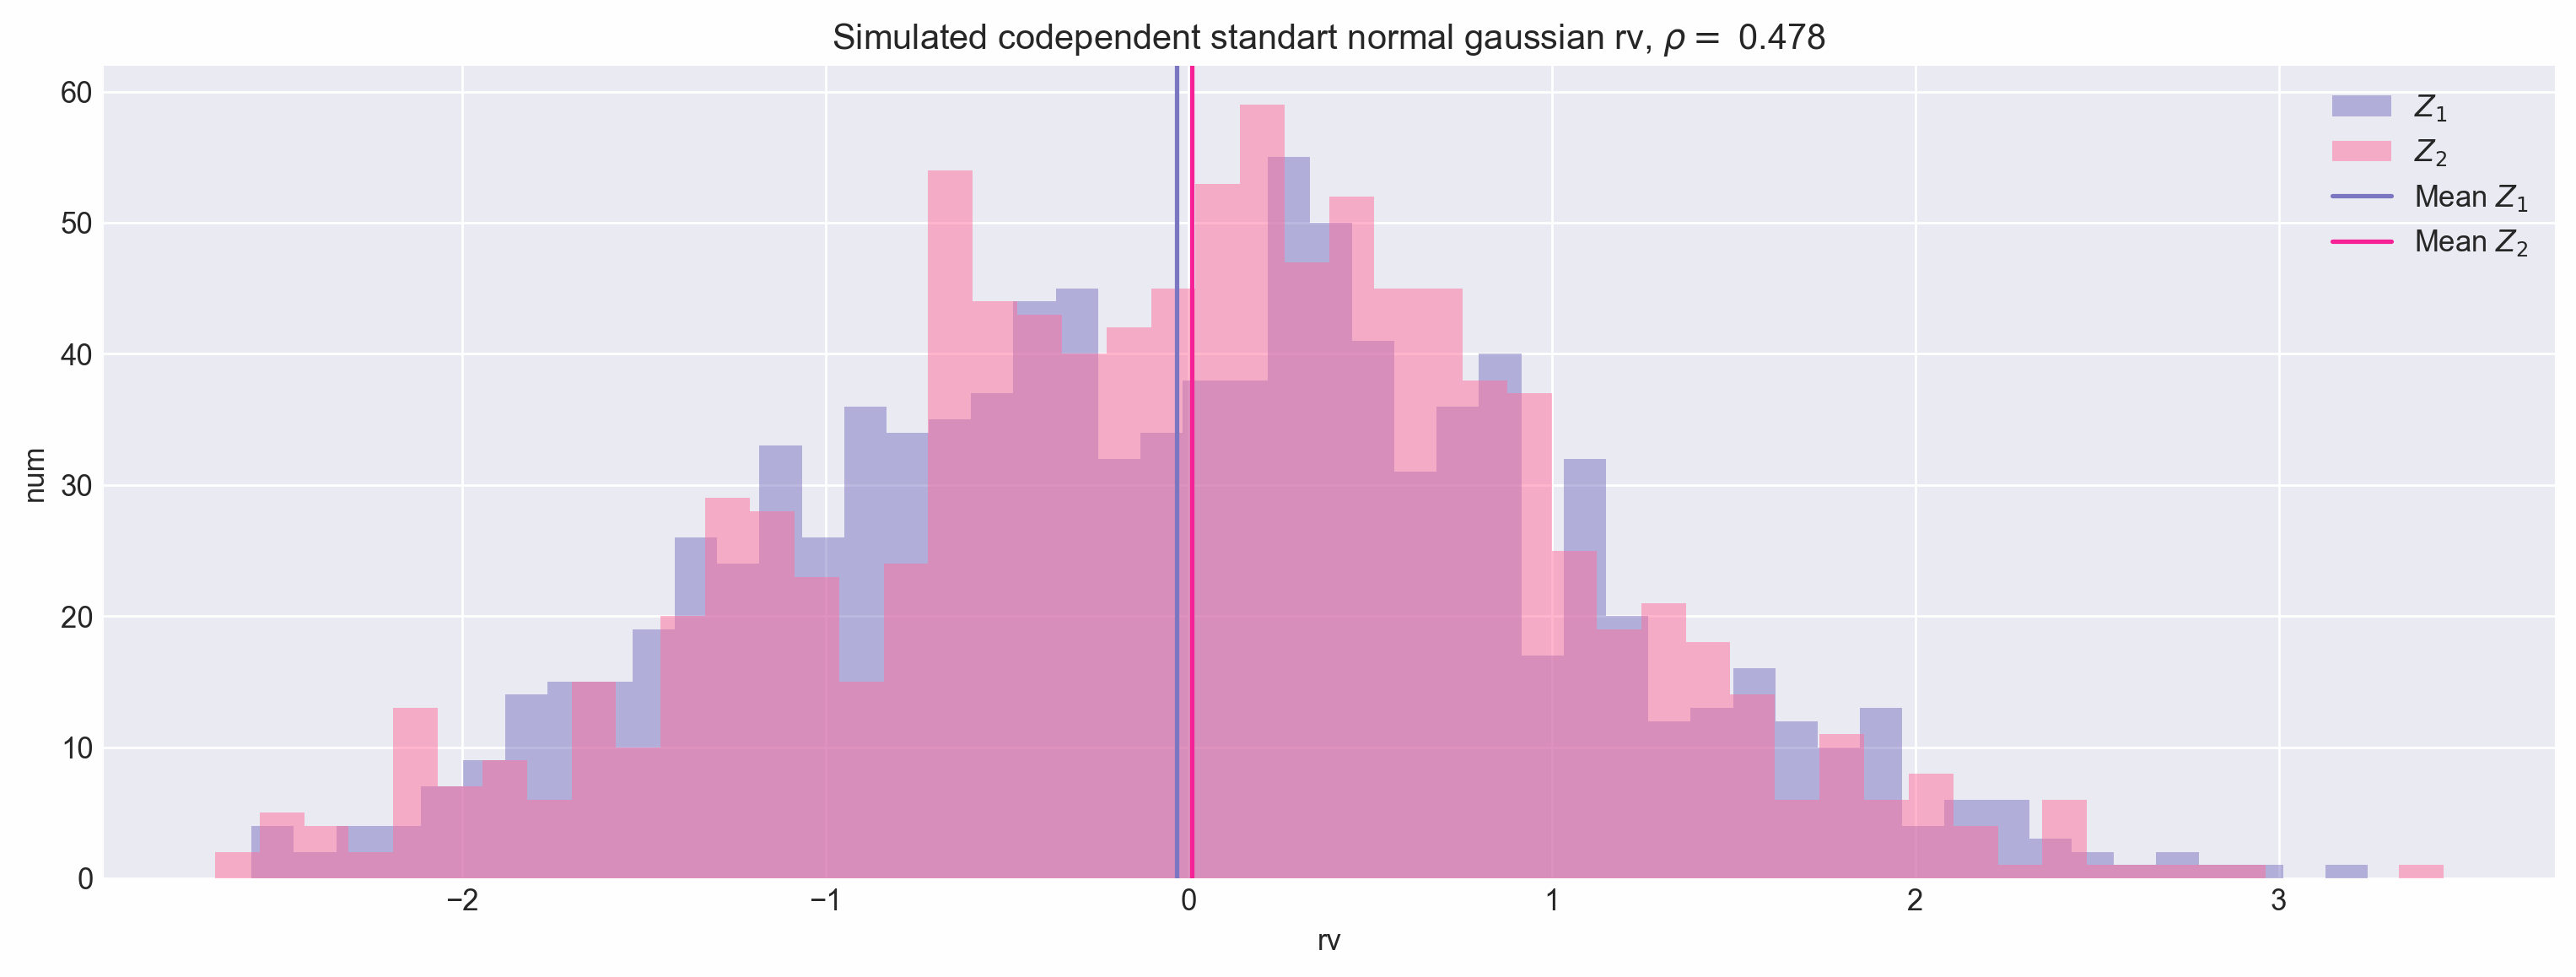

In [37]:
Z = generate_normal(n_sample, corr_matrix)

_, ax = plt.subplots(figsize=(15, 5), dpi=250)

i =0

ax.hist( Z[:, 0],bins=50, alpha=0.5, label = "$Z_1$") 
ax.hist(Z[:, 1],bins=50, alpha=0.5, label = "$Z_2$")  
ax.axvline(Z[:, 0].mean(), c="C0", label="Mean $Z_1$")
ax.axvline(Z[:, 1].mean(), c="C2", label="Mean $Z_2$")
ax.legend()
ax.set_xlabel("rv")
ax.set_ylabel("num")
ax.set_title(f"Simulated codependent standart normal gaussian rv, $\\rho =$ {corr_matrix[0,-1].round(3)}")
plt.show()

$$S^{SBER}_T = S^{SBER}_0 e^{(r - (\sigma^{SBER})^2/2)T + \sigma^{SBER} W^{SBER}_T},\\ \quad S^{MGNT}_T = S^{MGNT}_0 e^{(r - (\sigma^{MGNT})^2/2)T + \sigma^{MGNT} W^{MGNT}_T}$$

$$\text{Payoff}(S^{SBER}_T, S^{MGNT}_T) = \left(\frac{1}{2} \left(\frac{S^{SBER}_T}{S^{SBER}_0} + \frac{S^{MGNT}_T}{S^{MGNT}_0}\right) - 100\% \right)_{+}.$$

$$P = e^{-rT} \cdot \mathbb{E}^{\mathbb{Q}} [\text{Payoff}(S^{SBER}_T, S^{MGNT}_T)],$$

$$\mathbb{E}g(X_1, \dots, X_n) \approx \dfrac{1}{N} \sum_{k=1}^{N} g(X^k_1, \dots, X^k_n).$$

In [38]:
def option_price(n_sample: int, corr_matrix: np.ndarray):

    W = generate_normal(n_sample, corr_matrix)

    S_T_SBER = S0_SBER * np.exp((r - 0.5 * sigma0_SBER**2) * T + sigma0_SBER * np.sqrt(T) * W[:, 0].T)
    S_T_MGNT = S0_MGNT * np.exp((r - 0.5 * sigma0_MGNT**2) * T + sigma0_MGNT * np.sqrt(T) * W[:, 1].T)

    payoff = np.maximum(0.5 * (S_T_SBER / S0_SBER + S_T_MGNT / S0_MGNT) - 1, 0)
    price = np.exp(-r * T) * np.sum(payoff)/n_sample
    return price

In [39]:
def prices_MC(num_of_samples:list, corr_matrix: np.ndarray):
    price = np.zeros(len(num_of_samples))
    for i in range(len(num_of_samples)):
        price[i] = option_price(int(num_of_samples[i]), corr_matrix)
    return price

In [40]:
log_2_iteratinos = np.linspace(1, 25, 25)
num_of_samples = [2**i for i in range(log_2_iteratinos.shape[0])]

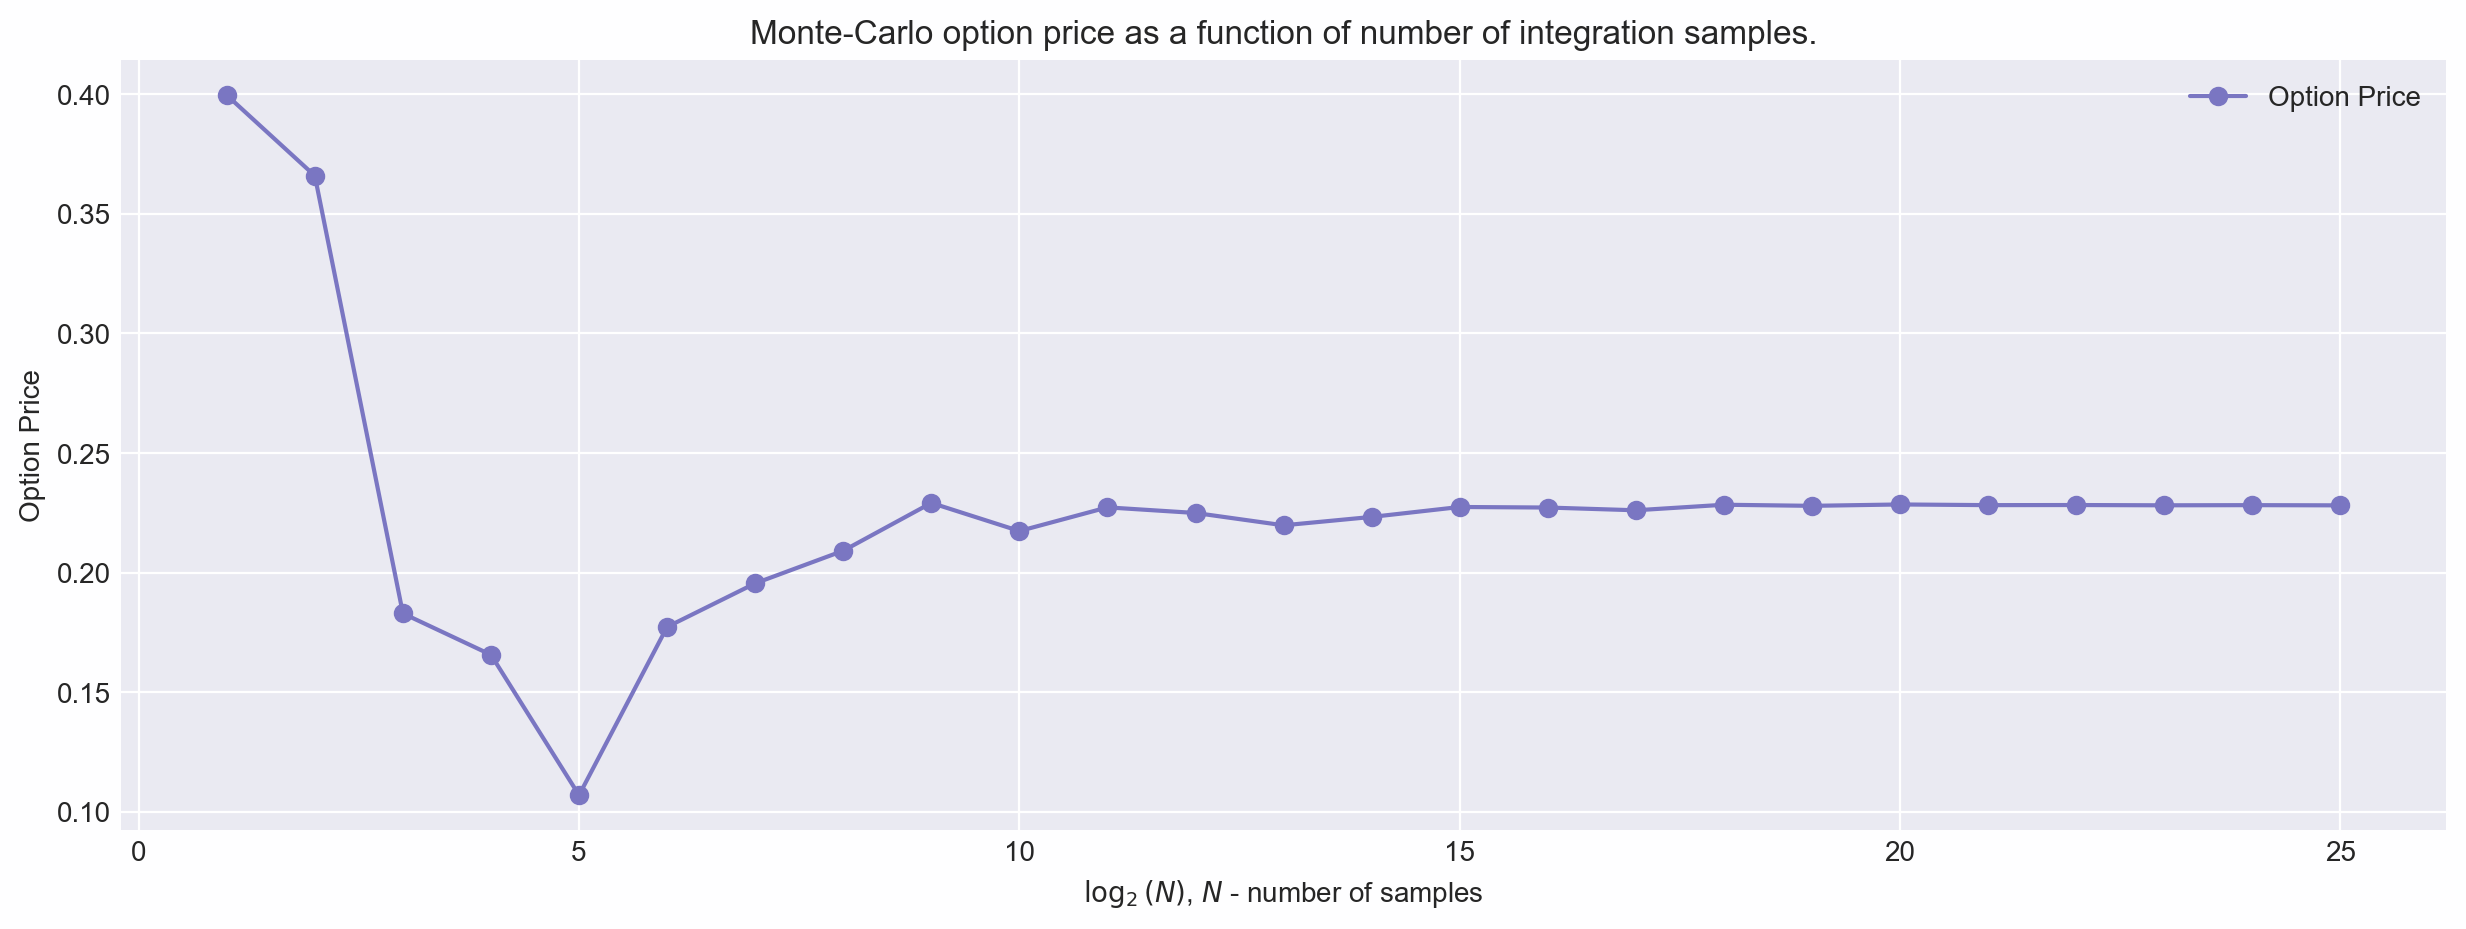

In [41]:
price = prices_MC(num_of_samples, corr_matrix)

_, ax = plt.subplots(figsize=(15, 5), dpi=200)
ax.plot(log_2_iteratinos, price, marker='o', label='Option Price')
ax.set_title('Monte-Carlo option price as a function of number of integration samples.')
ax.set_xlabel("$\\log_2(N)$, $N$ - number of samples")
ax.set_ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
price[-1]

np.float64(0.228072112176671)



The rate of convergence due to central limit theorem is $1/\sqrt{N}$.

In [43]:
one_over_sqrt_N = 1 / np.sqrt([2**i for i in range(log_2_iteratinos.shape[0])])

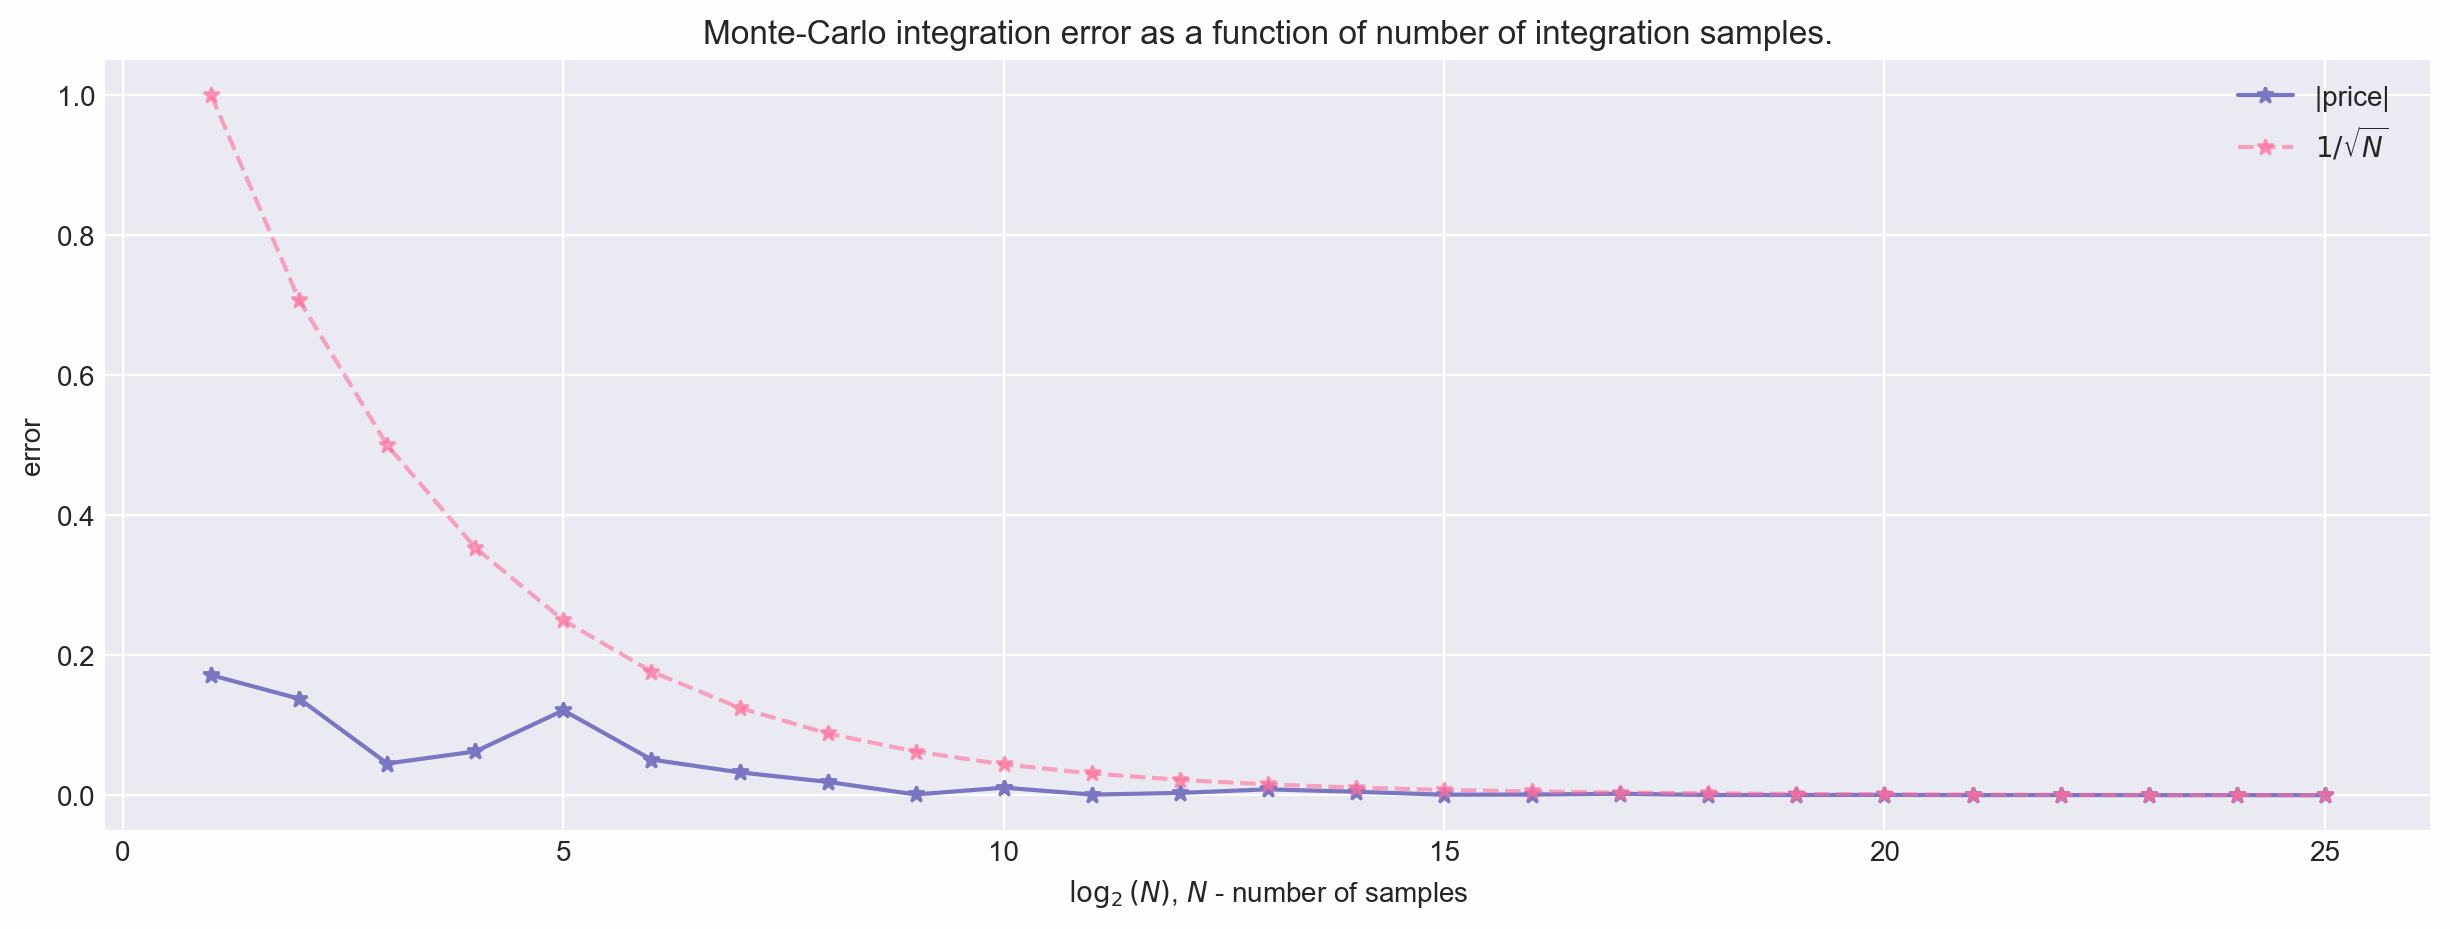

In [44]:
_, ax = plt.subplots(figsize=(15, 5), dpi=200)

ax.plot(log_2_iteratinos, np.abs(price - price[-1]), label="|price|  ", marker="*")
ax.plot(log_2_iteratinos, np.abs(one_over_sqrt_N - one_over_sqrt_N[-1]), label="$1/\\sqrt{N}$", marker="*", linestyle="--")
plt.title('Monte-Carlo integration error as a function of number of integration samples.')
plt.xlabel("$\\log_2(N)$, $N$ - number of samples")
plt.ylabel("error")
plt.legend()
plt.grid(True)
plt.show()

----------
----------

### 3. Implied volatilities interpolation

You are observing the following  implied volatilities for maturity $T=1$: 

$$K/S_0 = \{ 26\%, \quad 37\%, \quad 52\%, \quad 70\%, \quad 100\%, \quad 142\%, \quad 195\% \}$$
$$\sigma^{IV} = \{ 42.5\%, \quad 37.5\%, \quad 32.5\%, \quad 28.5\%, \quad 25\%, \quad 23\%, \quad 22\% \}$$

Assume that the risk-free interest rate is zero and the spot $S_0 = 1$.

Provide an interpolation algorithm (cubic splines, rational cubic splines or whatever you want) for the given implied volatilities. You **can not** use any algorithms built into scipy, numpy, or any other python module - use your one realization! Is your interpolation free of monotonicity ($C'(K) > 0$) and butterfly ($C''(K) > 0$) arbitrage? Your answer should contain a plot with interpolated implied volatilities as well as a numerical check that your interpolation does not violate no-arbitrage conditions described above. 

--------

In [45]:
from typing import Union, Iterable

In [46]:
S_0 = 1
r = 0.20
K = np.array([0.26, 0.37, 0.52, 0.7, 1, 1.42, 1.95]) * S_0
IV = np.array([0.425, 0.375, 0.325, 0.285, 0.25, 0.23, 0.22])


* The Black option formula can be written as 
$$
\text{Black}(F, K, \sigma, T, \text{DF}, \theta) = \text{DF} \cdot \theta \cdot F \cdot [\Phi(- \theta \cdot (\tfrac{z}{\sigma \sqrt{T}} - \tfrac{\sigma \sqrt{T}}{2})) - e^{z} \cdot \Phi(- \theta \cdot (\tfrac{z}{\sigma \sqrt{T}} + \tfrac{\sigma \sqrt{T}}{2}))],
$$

&ensp;&emsp;&emsp; where
$z := \ln{(K/F)} $ is the log-moneyness, $K$ and $T$ are strike and maturity of the option's contract, $DF$ and $F$ are discount factor and forward up to maturity $T$, $\sigma$ is the volatility and $\theta = \pm 1$ for calls/puts. 


&ensp;&emsp;&emsp; $\Phi(\cdot)$ is the cumulative density function of standard normal random variable. 

In [47]:
def black(log_moneyness: Union[float, np.ndarray], forward: float, vol: Union[np.ndarray, float], 
          df: float = 1, T: float = 1, theta: float = 1) -> Union[float, np.ndarray]:
    total_vol = vol * np.sqrt(T)
    d_1 = - theta * (log_moneyness / total_vol - total_vol / 2)
    d_2 = - theta * (log_moneyness / total_vol + total_vol / 2)   
    return df * theta * forward * (norm.cdf(d_1) - np.exp(log_moneyness) * norm.cdf(d_2))

In [48]:
#forward, df, T = 1.0, 1.0, 1.0
T = 1.0

forward, df = S_0*np.exp(r*T), np.exp(-r*T)

In [49]:
T, forward, df

(1.0, np.float64(1.2214027581601699), np.float64(0.8187307530779818))

In [50]:
moneyness_wide_range = K/forward
vol_wide_range = IV

In [51]:
calls_wide_range = black(log_moneyness=np.log(moneyness_wide_range),
                          forward=forward, 
                          vol=IV,
                          df=df, T=T, theta=1)

In [52]:
def monotonicity_arbitrage(c: np.ndarray, k: np.ndarray):
    arbitrage_detected = False
    for i in range(len(c) - 1):
        if c[i + 1] >= c[i]:
            print("A monotonicity arbitrage was detected with strikes {} and {}".format(k[i],k[i+1]))
            arbitrage_detected = True
            
    if not arbitrage_detected:
        print("No arbitrage was detected.")

In [53]:
def convexity_arbitrage(c: np.ndarray, k: np.ndarray):
    arbitrage_detected = False
    for i in range(1, len(c) - 1):
        check_to = c[i-1] / (k[i] - k[i-1]) - c[i] * (1/(k[i] - k[i-1]) + 1/(k[i+1] - k[i])) + c[i+1] / (k[i+1] - k[i]) 
        if check_to < 0:
            print("A convexity arbitrage was detected with strikes {}, {} and {}".format(k[i-1], k[i], k[i+1]))
            arbitrage_detected = True

    if not arbitrage_detected:
        print("No arbitrage was detected.")

In [54]:
#chek given data

monotonicity_arbitrage(c=calls_wide_range, k=K)
convexity_arbitrage(c=calls_wide_range, k=K)

No arbitrage was detected.
No arbitrage was detected.


In [55]:
dense_grid = np.linspace(moneyness_wide_range[0], moneyness_wide_range[-1], 100)
dense_grid = np.unique(np.append(dense_grid, K[:-1]))

In [56]:
def r_boundary(d: Iterable, f: Iterable, x: Iterable):
    r = []
    for i in range(len(x) - 1):
        Delta_i = (f[i + 1] - f[i]) / (x[i + 1] - x[i])
        r.append(max((d[i + 1] - d[i]) / (d[i + 1] - Delta_i), (d[i + 1] - d[i]) / (Delta_i - d[i])))
    return r

def d_1_approx(x_1: float, x_2: float, x_3: float, f_1: float, f_2: float, f_3: float):
    Delta_1 = - (f_2 - f_1) / (x_2 - x_1)
    Delta_31 = - (f_3 - f_1) / (x_3 - x_1)
    return - (Delta_1 ** ((x_3 - x_1) / (x_3 - x_2))) * (Delta_31 ** (-(x_2 - x_1) / (x_3 - x_2)))

def d_approx(x_1: float, x_2: float, x_3: float, f_1: float, f_2: float, f_3: float):
    Delta_1 = - (f_2 - f_1) / (x_2 - x_1)
    Delta_2 = - (f_3 - f_2) / (x_3 - x_2)
    return - (Delta_1 ** ((x_3 - x_2) / (x_3 - x_1))) * (Delta_2 ** ((x_2 - x_1) / (x_3 - x_1)))

def d_n_approx(x_n_2: float, x_n_1: float, x_n: float, f_n_2: float, f_n_1: float, f_n: float):
    Delta_n_1 = - (f_n - f_n_1) / (x_n - x_n_1)
    Delta_nn_2 = - (f_n - f_n_2) / (x_n - x_n_2)
    return - (Delta_n_1 ** ((x_n - x_n_2) / (x_n_1 - x_n_2))) * (Delta_nn_2 ** (-(x_n - x_n_1) / (x_n_1 - x_n_2)))

def slopes_estimation(x: list, y: list):
    slopes = []
    for i in range(len(x)):
        if i == 0:
            slopes.append(d_1_approx(x_1=x[i], x_2=x[i+1], x_3=x[i+2], f_1=y[i], f_2=y[i+1], f_3=y[i+2]))
        elif i == len(x) - 1:
            slopes.append(d_n_approx(x_n_2=x[i-2], x_n_1=x[i-1], x_n=x[i], f_n_2=y[i-2], f_n_1=y[i-1], f_n=y[i]))
        else:
            slopes.append(d_approx(x_1=x[i-1], x_2=x[i], x_3=x[i+1], f_1=y[i-1], f_2=y[i], f_3=y[i+1]))
    
    return slopes

In [57]:
ivs_slopes = slopes_estimation(x=np.log(moneyness_wide_range), y=vol_wide_range)

If $x \in [x_i, x_{i+1}]$

$$S(x) = S_i(x) = a_i + b_i(x- x_i) + c_i(x- x_i)^2  + d_i(x-x_i)^3 $$

* $a_i = S_i(x_i) (= y(x_i))$
* $ b_i =  S'_i(x_i) (= d(x_i))$
* $c_i = S''_i(x_i)/2$
* $d_i = S'''_i(x_i)/6$


And by next conditions we can derive expressions for $c_i, d_i$:
1) $S_i(x_{i+1}) = S_{i+1}(x_{i+1}) \quad \Rightarrow \quad a_i+ b_ih_i+ c_ih_i^2 + d_ih_i^3 = a_{i+1}$ 

2) $S'_i(x_{i+1}) = S'_{i+1}(x_{i+1}) \quad \Rightarrow \quad b_i + 2c_ih_i + 3d_ih_i^2 = b_{i+1}$ 

3) $S''_i(x_{i+1}) = S''_{i+1}(x_{i+1})\quad \Rightarrow \quad  2c_i + 6d_ih_i = c_{i+1}$ 

where $h_{i} = x_{i+1} - x_{i}$. Solving equations above, we have:

* $c_i = \frac{3(a_{i+1}- a_i)}{h_{i}^2} - \frac{2b_i + b_{i+1}}{h_{i}}$

* $d_i = \frac{2 (a_i - a_{i+1})}{h_{i}^3} + \frac{b_{i+1}+ b_i}{h_{i}^2}$


In this case there are no arbitrage

In [58]:
class CubicSplineInterpolator:
    def __init__(self, x: np.ndarray, y: np.ndarray, d: np.ndarray):
        """
        x: array of x-coordinates (must be sorted in ascending order).
        y: array of y-coordinates corresponding to x.
        d: array of derivatives (slopes) at each x-coordinate.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.d = np.array(d)
        self.n = len(x) - 1 

    
        self.a = y[:-1]  
        self.b = d[:-1]  
        self.c = np.zeros(self.n) 
        self.d_coef = np.zeros(self.n)

        h = np.diff(self.x) 

        for i in range(self.n):
            self.c[i] = (3 * (y[i + 1] - y[i]) / h[i]**2 - (2 * d[i] + d[i + 1]) / h[i])
            self.d_coef[i] = (2 * (y[i] - y[i + 1]) / h[i]**3 + (d[i] + d[i + 1]) / h[i]**2)

    def __call__(self, x_eval: np.ndarray) -> np.ndarray:
        """
        Evaluate the cubic spline at given points.
        x_eval: array of x-coordinates where the spline is evaluated.
        """
        x_eval = np.array(x_eval)
        results = np.zeros_like(x_eval)

        for i, x_val in enumerate(x_eval):
            # Find the segment containing x_val
            idx = np.searchsorted(self.x, x_val) - 1
            if idx < 0:
                idx = 0
            elif idx >= self.n:
                idx = self.n - 1

            dx = x_val - self.x[idx]
            results[i] = (
                self.a[idx]
                + self.b[idx] * dx
                + self.c[idx] * dx**2
                + self.d_coef[idx] * dx**3
            )
        return results

In [59]:
interpolated_vols = CubicSplineInterpolator(x=np.log(moneyness_wide_range), y=vol_wide_range, d=ivs_slopes)
interpolated_vols_dense_grid = interpolated_vols(np.log(dense_grid))

In [60]:
interpolated_calls_ns_via_vols_interpolation = black(log_moneyness=np.log(dense_grid), 
                                                     forward=forward, vol=interpolated_vols_dense_grid,
                                                     df=df, T=T, theta=1)

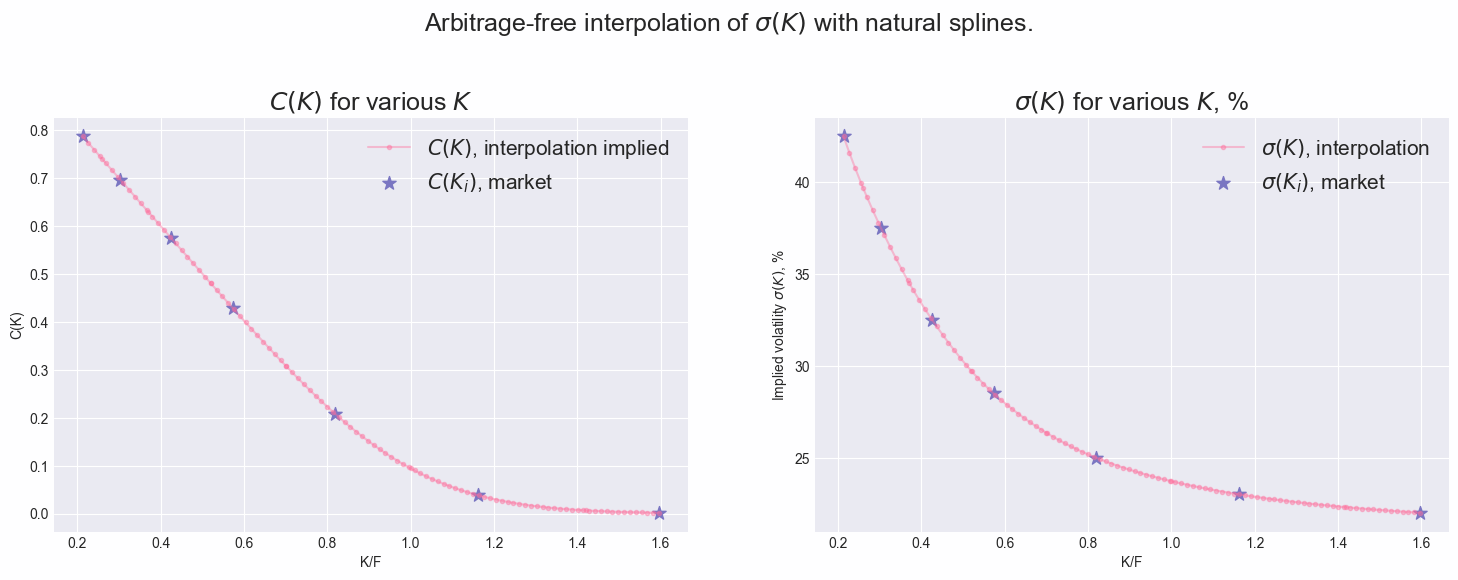

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
plt.rcParams.update({'font.size': 15, "axes.labelsize": 15})

ax[0].plot(dense_grid, interpolated_calls_ns_via_vols_interpolation, label="$C(K)$, interpolation implied", marker=".", color='C1',alpha = 0.4)
ax[0].scatter(moneyness_wide_range, calls_wide_range, label="$C(K_i)$, market", marker="*", color='C0', s=100)

ax[1].plot(dense_grid, interpolated_vols_dense_grid * 100, label="$\\sigma(K)$, interpolation", marker=".", color='C1',alpha = 0.4)
ax[1].scatter(moneyness_wide_range, vol_wide_range * 100, label="$\\sigma(K_i)$, market", marker="*", color='C0', s=100)

plt.suptitle("Arbitrage-free interpolation of $\\sigma(K)$ with natural splines.")
plt.subplots_adjust(top=0.8)
ax[0].set_title('$C(K)$ for various $K$'), ax[0].set_xlabel('K/F'), ax[0].set_ylabel('C(K)'), ax[0].legend()
ax[1].set_title('$\\sigma(K)$ for various $K$, %'), ax[1].set_xlabel('K/F'), ax[1].set_ylabel('Implied volatility $\\sigma(K)$, %'), ax[1].legend()
ax[0].grid(True), ax[1].grid(True)
plt.show()

In [62]:
#chek interpolated data
monotonicity_arbitrage(c=interpolated_calls_ns_via_vols_interpolation, k=dense_grid)
convexity_arbitrage(c=interpolated_calls_ns_via_vols_interpolation, k=dense_grid)

No arbitrage was detected.
No arbitrage was detected.


---------
----------

### 4. Pricing options within finite-differencing framework

Your task is to price European/American options within finite-differencing approach. You may assume you are given an implied volatilities (together with your interplation method) from the previous task. 

1. Price within a finite-differencing method a European put option with strike $K=70\%$ and a European call option with strike $K = 130\%$. Use any numerical scheme you wish. Compare your results with the ones obtained analytically from Black-Scholes formula. How your results differ from the analytic ones?

2. Price within a finite-differencing method an American put option with strike $K=70\%$. Please note that an American option can be exercised at any time before the maturity if its intrinsic value is greater than calculated option price at that step. Use any numerical scheme you wish. Please describe the way how option's "American" property affects your finite-differencing algorithm when you are stepping in time. How its price differs from the price of European option with the same strike? 

You may use your own implementation of finite differencing algorithm or the one presented on the seminar.

-----

In [63]:
K_put = 0.7
K_call = 1.30


In [64]:
from pricer import price, OptionType
from pde_solver import solve_1d_pde, FiniteDifferencingScheme

##### 1. European options

>1. Price within a finite-differencing method a European put option with strike $K=70\%$ and a European call option with strike $K = 130\%$. Use any numerical scheme you wish. Compare your results with the ones obtained analytically from Black-Scholes formula. How your results differ from the analytic ones?

$$dX_t = \sigma dW_t$$

$$X_t = \sigma W_t \sim N(0, t)$$


$$
\boxed{
x = \sigma W_t
} 
$$

+ **Boundary values**

$$x_{min} = - n_{std} \cdot \sigma \cdot \sqrt{T}, \quad x_{max} = n_{std} \cdot \sigma \cdot \sqrt{T},$$

where $n_{std}$ is the number of standard deviations which we wish to cover (for instance, $n_{std} = 4$). Notice that $\sigma \sqrt{T}$ is, effectively, a standard deviation of $W_T$.

<ins> Put options </ins>:

$$
\begin{align*}
u^{put}(t, x_{max}) &= 0, \\
u^{put}(t, x_{min}) &= \mathbb{E} \left[\left( K - S_T \right)_{+} | \sigma W_t = x_{min} \right]  = \mathbb{E} \left[ \left( K - S_0 e^{(r - \sigma^2/2)T + \sigma W_{T}} \right)_{+} \Big| \sigma W_t = x_{min} \right] \\
&=  \mathbb{E} \left[ \left( K - S_0 e^{(r - \sigma^2/2)T + \sigma W_t + \sigma W_{T-t}} \right)_{+} \Big| \sigma W_t = x_{min}\right] = \mathbb{E} \left[ \left( K - S_0 e^{(r - \sigma^2/2)T + x_{min} + \sigma W_{T-t}} \right)_{+}\right] \\
&\approx \mathbb{E} \left[ K - S_0 e^{(r - \sigma^2/2)T + x_{min} + \sigma W_{T-t}} \right] = K - S_0 e^{(r - \sigma^2/2)T + x_{min}} \cdot \mathbb{E} \left[ e^{\sigma W_{T-t}} \right] = \\
&= K - S_0 e^{(r - \sigma^2/2)T + x_{min}} \cdot e^{\sigma^2(T-t)/2} = K - S_0e^{rT - \sigma^2 t/2 + x_{min}} = \\
&= \boxed{e^{r(T-t)} \left( Ke^{-r(T-t)} - S_0  e^{x_{min} + (r - \sigma^2 / 2)  t} \right)}.\\
\end{align*}
$$

<ins> Call options </ins>:
 
$$
\begin{align*}
u^{call}(t, x_{min}) &= 0, \\
u^{call}(t, x_{max}) &= \mathbb{E} \left[\left( S_T - K \right)_{+} | \sigma W_t = x_{max} \right]  = \mathbb{E} \left[ \left( S_0 e^{(r - \sigma^2/2)T + \sigma W_{T}} - K\right)_{+} \Big| \sigma W_t = x_{max} \right] \\
&=  \mathbb{E} \left[ \left( S_0 e^{(r - \sigma^2/2)T + \sigma W_t + \sigma W_{T-t}} - K\right)_{+} \Big| \sigma W_t = x_{max}\right] = \mathbb{E} \left[ \left(S_0 e^{(r - \sigma^2/2)T + x_{max} + \sigma W_{T-t}} - K \right)_{+}\right] \\
&\approx \mathbb{E} \left[ S_0 e^{(r - \sigma^2/2)T + x_{max} + \sigma W_{T-t}}  - K\right] = S_0 e^{(r - \sigma^2/2)T + x_{max}} - K \cdot \mathbb{E} \left[ e^{\sigma W_{T-t}} \right] = \\
&= S_0 e^{(r - \sigma^2/2)T + x_{max}} \cdot e^{\sigma^2(T-t)/2} - K = S_0e^{rT - \sigma^2 t/2 + x_{max}} - K = \\
&= \boxed{e^{r(T-t)} \left( S_0  e^{x_{max} + (r - \sigma^2 / 2)  t} - Ke^{-r(T-t)} \right)}.\\
\end{align*}
$$

+ **Terminal condition**

$$t_{start} = 0, \quad t_{end} = T.$$

$$
\begin{align*}
u^{put}(T, x) =  \mathbb{E} \left[\left(K - S_T \right)_{+} | \sigma W_T = x \right] &=  \mathbb{E} \left[ \left( K - S_0 e^{(r - \sigma^2/2)T + \sigma W_{T}} \right)_{+} \Big| \sigma W_T = x \right] \\
&= \boxed{\left( K - S_0 e^{(r - \sigma^2/2)T + x} \right)_{+}}.
\end{align*}
$$

$$
\begin{align*}
u^{call}(T, x) =  \mathbb{E} \left[\left(S_T \right)_{+} - K| \sigma W_T = x \right] &=  \mathbb{E} \left[ \left( S_0 e^{(r - \sigma^2/2)T + \sigma W_{T}} - K\right)_{+} \Big| \sigma W_T = x \right] \\
&= \boxed{\left( S_0 e^{(r - \sigma^2/2)T + x} - K\right)_{+}}.
\end{align*}
$$

In [65]:
spot = S_0
maturity = T
r = 0.00

In [66]:
F, df = spot * np.exp(r * maturity), np.exp(-r*maturity)

In [67]:
moneyness_wide_range = K/F
vol_wide_range = IV
ivs_slopes = slopes_estimation(x=np.log(moneyness_wide_range), y=vol_wide_range)
interpolated_vols = CubicSplineInterpolator(x=np.log(moneyness_wide_range), y=vol_wide_range, d=ivs_slopes)

In [68]:
#sigma_call = interpolated_vols(np.log(np.array([K_call/F])))
#sigma_put = interpolated_vols(np.log(np.array([K_put/F])))

In [69]:
#где-то была ошибка, поэтому, пойду методом "вылить воду из чайника", который точно сработает
dense_grid = np.linspace(moneyness_wide_range[0], moneyness_wide_range[-1], 100)
dense_grid = np.unique(np.append(dense_grid, K_put/F))
dense_grid = np.unique(np.append(dense_grid, K_call/F))

In [70]:

for i in range(len(dense_grid)):
    if(dense_grid[i]== K_put/F):
        index_put = i
    if(dense_grid[i]== K_call/F):
        index_call = i


In [71]:

index_put,dense_grid[index_put],index_call,dense_grid[index_call]

(26, np.float64(0.7), 62, np.float64(1.3))

In [72]:
interpolated_vols_dense_grid = interpolated_vols(np.log(dense_grid))
interpolated_calls_ns_via_vols_interpolation = black(log_moneyness=np.log(dense_grid), 
                                                     forward=F, vol=interpolated_vols_dense_grid,
                                                     df=df, T=T, theta=1)

In [73]:
sigma_call = interpolated_vols_dense_grid[index_call]
sigma_put = interpolated_vols_dense_grid[index_put]

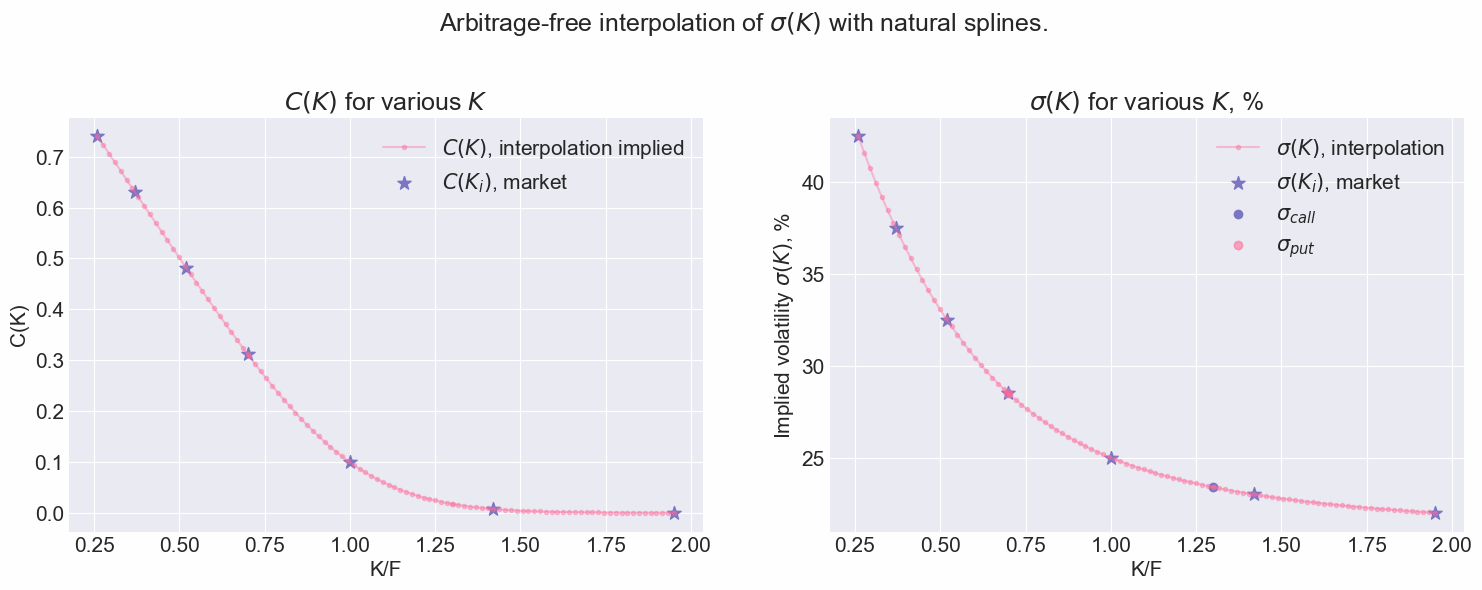

In [74]:
calls_wide_range = black(log_moneyness=np.log(moneyness_wide_range),
                          forward=F, 
                          vol=IV,
                          df=df, T=T, theta=1)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
plt.rcParams.update({'font.size': 15, "axes.labelsize": 15})

ax[0].plot(dense_grid, interpolated_calls_ns_via_vols_interpolation, label="$C(K)$, interpolation implied", marker=".", color='C1',alpha = 0.4)
ax[0].scatter(moneyness_wide_range, calls_wide_range, label="$C(K_i)$, market", marker="*", color='C0', s=100)

ax[1].plot(dense_grid, interpolated_vols_dense_grid * 100, label="$\\sigma(K)$, interpolation", marker=".", color='C1',alpha = 0.4)
ax[1].scatter(moneyness_wide_range, vol_wide_range * 100, label="$\\sigma(K_i)$, market", marker="*", color='C0', s=100)

ax[1].scatter(K_call/F, sigma_call*100, marker = "o", label = '$\\sigma_{call}$')
ax[1].scatter(K_put/F, sigma_put*100, marker = "o" , label = '$\\sigma_{put}$')

plt.suptitle("Arbitrage-free interpolation of $\\sigma(K)$ with natural splines.")
plt.subplots_adjust(top=0.8)
ax[0].set_title('$C(K)$ for various $K$'), ax[0].set_xlabel('K/F'), ax[0].set_ylabel('C(K)'), ax[0].legend()
ax[1].set_title('$\\sigma(K)$ for various $K$, %'), ax[1].set_xlabel('K/F'), ax[1].set_ylabel('Implied volatility $\\sigma(K)$, %'), ax[1].legend()
ax[0].grid(True), ax[1].grid(True)
plt.show()

In [75]:
number_of_time_steps = 301*4*4
finite_differencing_spacial_levels = 501*2*2
number_of_std_deviations = 4
scheme_type = FiniteDifferencingScheme.Implicit


In [76]:
pde_coefficients = lambda _:  {"U": 0, "U_t": 1., "U_x": 0, "U_xx": 0.5 * sigma_call ** 2}
trade_values_calls = price(maturity=maturity, strike=K_call, option_type=OptionType.CALL,
                                 number_of_spatial_levels=finite_differencing_spacial_levels, number_of_time_steps=number_of_time_steps,
                                 pde_coefficients=pde_coefficients, scheme=scheme_type, spot=spot,
                                 volatility=sigma_call, interest_rate=r, number_of_std_deviations=number_of_std_deviations)

trade_values_calls_analytic = black(log_moneyness=np.log(K_call / F),
                                          forward=F,
                                          vol=sigma_call,
                                          df = df,
                                          T=maturity,
                                          theta=1)

In [77]:
pde_coefficients = lambda _:  {"U": 0, "U_t": 1., "U_x": 0, "U_xx": 0.5 * sigma_put ** 2}
trade_values_puts= price(maturity=maturity, strike=K_put, option_type=OptionType.PUT,
                                 number_of_spatial_levels=finite_differencing_spacial_levels, number_of_time_steps=number_of_time_steps,
                                 pde_coefficients=pde_coefficients, scheme=scheme_type, spot=spot,
                                 volatility=sigma_put, interest_rate=r, number_of_std_deviations=number_of_std_deviations)

trade_values_puts_analytic = black(log_moneyness=np.log(K_put /F),
                                          forward=F,
                                          vol=sigma_put,
                                          df = df,
                                          T=maturity,
                                          theta=-1)

In [78]:
from prettytable import PrettyTable

my_table = PrettyTable()
my_table.field_names = [f"RESULTS, r = {r}", f"European CALL (K = {K_call*100}%, sigma = {sigma_call})", f"European PUT (K = {K_put*100}%, sigma = {sigma_put})"]
my_table.add_row(["Price within a finite-differencing method", trade_values_calls, trade_values_puts])
my_table.add_row(["Price from Black-Scholes formula", trade_values_calls_analytic, trade_values_puts_analytic])
my_table.add_row(["error",np.abs(trade_values_calls - trade_values_calls_analytic), np.abs(trade_values_puts - trade_values_puts_analytic)])

print(my_table)

+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
|              RESULTS, r = 0.0             | European CALL (K = 130.0%, sigma = 0.23398898531721918) | European PUT (K = 70.0%, sigma = 0.285) |
+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
| Price within a finite-differencing method |                   0.017472581888532627                  |           0.01194173113303372           |
|      Price from Black-Scholes formula     |                   0.01747121463796919                   |           0.011941761373729876          |
|                   error                   |                  1.3672505634367005e-06                 |          3.024069615553682e-08          |
+-------------------------------------------+---------------------------------------------------------+---------------------

In [79]:
print(f"Results: \nEuropean CALL option with K = {K_call*100}%, sigma = {sigma_call}, S0 = {spot}, r = {r*100}% \n")

print(f"Price within a finite-differencing method: {trade_values_calls} ")
print(f"Price from Black-Scholes formula: {trade_values_calls_analytic} ")
print(f"error: {np.abs(trade_values_calls - trade_values_calls_analytic)} ")

print("------------------------------------------------------------------")
print(f"\nEuropean PUT option with K = {K_put*100}%, sigma = {sigma_put}, S0 = {spot}, r = {r*100}% \n")

print(f"Price within a finite-differencing method: {trade_values_puts} ")
print(f"Price from Black-Scholes formula: {trade_values_puts_analytic} ")
print(f"error: {np.abs(trade_values_puts - trade_values_puts_analytic)} ")


Results: 
European CALL option with K = 130.0%, sigma = 0.23398898531721918, S0 = 1, r = 0.0% 

Price within a finite-differencing method: 0.017472581888532627 
Price from Black-Scholes formula: 0.01747121463796919 
error: 1.3672505634367005e-06 
------------------------------------------------------------------

European PUT option with K = 70.0%, sigma = 0.285, S0 = 1, r = 0.0% 

Price within a finite-differencing method: 0.01194173113303372 
Price from Black-Scholes formula: 0.011941761373729876 
error: 3.024069615553682e-08 


все что было выше в одной функции:

In [80]:
def magic_interpolation(r:float):
    spot = S_0
    maturity = T
    F, df = spot * np.exp(r * maturity), np.exp(-r*maturity)

    moneyness_wide_range = K/F
    vol_wide_range = IV
    ivs_slopes = slopes_estimation(x=np.log(moneyness_wide_range), y=vol_wide_range)
    interpolated_vols = CubicSplineInterpolator(x=np.log(moneyness_wide_range), y=vol_wide_range, d=ivs_slopes)

    
    dense_grid = np.linspace(moneyness_wide_range[0], moneyness_wide_range[-1], 100)
    dense_grid = np.unique(np.append(dense_grid, K_put/F))
    dense_grid = np.unique(np.append(dense_grid, K_call/F))

    
    for i in range(len(dense_grid)):
        if(dense_grid[i]== K_put/F):
            index_put = i
        if(dense_grid[i]== K_call/F):
            index_call = i
    
    interpolated_vols_dense_grid = interpolated_vols(np.log(dense_grid))
    interpolated_calls_ns_via_vols_interpolation = black(log_moneyness=np.log(dense_grid), 
                                                         forward=F, vol=interpolated_vols_dense_grid,
                                                         df=df, T=T, theta=1)
    

    sigma_call = interpolated_vols_dense_grid[index_call]
    sigma_put = interpolated_vols_dense_grid[index_put]

    number_of_time_steps = 301
    finite_differencing_spacial_levels = 501
    number_of_std_deviations = 4
    scheme_type = FiniteDifferencingScheme.Implicit
    
    pde_coefficients = lambda _:  {"U": 0, "U_t": 1., "U_x": 0, "U_xx": 0.5 * sigma_call ** 2}
    trade_values_calls = price(maturity=maturity, strike=K_call, option_type=OptionType.CALL,
                                     number_of_spatial_levels=finite_differencing_spacial_levels, number_of_time_steps=number_of_time_steps,
                                     pde_coefficients=pde_coefficients, scheme=scheme_type, spot=spot,
                                     volatility=sigma_call, interest_rate=r, number_of_std_deviations=number_of_std_deviations)
    
    trade_values_calls_analytic = black(log_moneyness=np.log(K_call / F),
                                              forward=F,
                                              vol=sigma_call,
                                              df = df,
                                              T=maturity,
                                              theta=1)
    
    pde_coefficients = lambda _:  {"U": 0, "U_t": 1., "U_x": 0, "U_xx": 0.5 * sigma_put ** 2}
    trade_values_puts= price(maturity=maturity, strike=K_put, option_type=OptionType.PUT,
                                     number_of_spatial_levels=finite_differencing_spacial_levels, number_of_time_steps=number_of_time_steps,
                                     pde_coefficients=pde_coefficients, scheme=scheme_type, spot=spot,
                                     volatility=sigma_put, interest_rate=r, number_of_std_deviations=number_of_std_deviations)
    
    trade_values_puts_analytic = black(log_moneyness=np.log(K_put /F),
                                              forward=F,
                                              vol=sigma_put,
                                              df = df,
                                              T=maturity,
                                              theta=-1)
    my_table = PrettyTable()
    my_table.field_names = [f"RESULTS, r = {r}", f"European CALL (K = {K_call*100}%, sigma = {sigma_call})", f"European PUT (K = {K_put*100}%, sigma = {sigma_put})"]
    my_table.add_row(["Price within a finite-differencing method", trade_values_calls, trade_values_puts])
    my_table.add_row(["Price from Black-Scholes formula", trade_values_calls_analytic, trade_values_puts_analytic])
    my_table.add_row(["error",np.abs(trade_values_calls - trade_values_calls_analytic), np.abs(trade_values_puts - trade_values_puts_analytic)])

    print(my_table)
    return trade_values_calls, trade_values_puts
    

In [81]:
r = 0.02
magic_interpolation(r)

+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
|             RESULTS, r = 0.02             | European CALL (K = 130.0%, sigma = 0.23398898531721918) | European PUT (K = 70.0%, sigma = 0.285) |
+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
| Price within a finite-differencing method |                   0.020473241119287583                  |           0.010192471785856985          |
|      Price from Black-Scholes formula     |                   0.020456848227850957                  |           0.01019017785083058           |
|                   error                   |                  1.6392891436626394e-05                 |          2.293935026405694e-06          |
+-------------------------------------------+---------------------------------------------------------+---------------------

(array(0.02047324), array(0.01019247))

##### 2. American put option

>2. Price within a finite-differencing method an American put option with strike $K=70\%$. Please note that an American option can be exercised at any time before the maturity if its intrinsic value is greater than calculated option price at that step. Use any numerical scheme you wish. Please describe the way how option's "American" property affects your finite-differencing algorithm when you are stepping in time. How its price differs from the price of European option with the same strike?

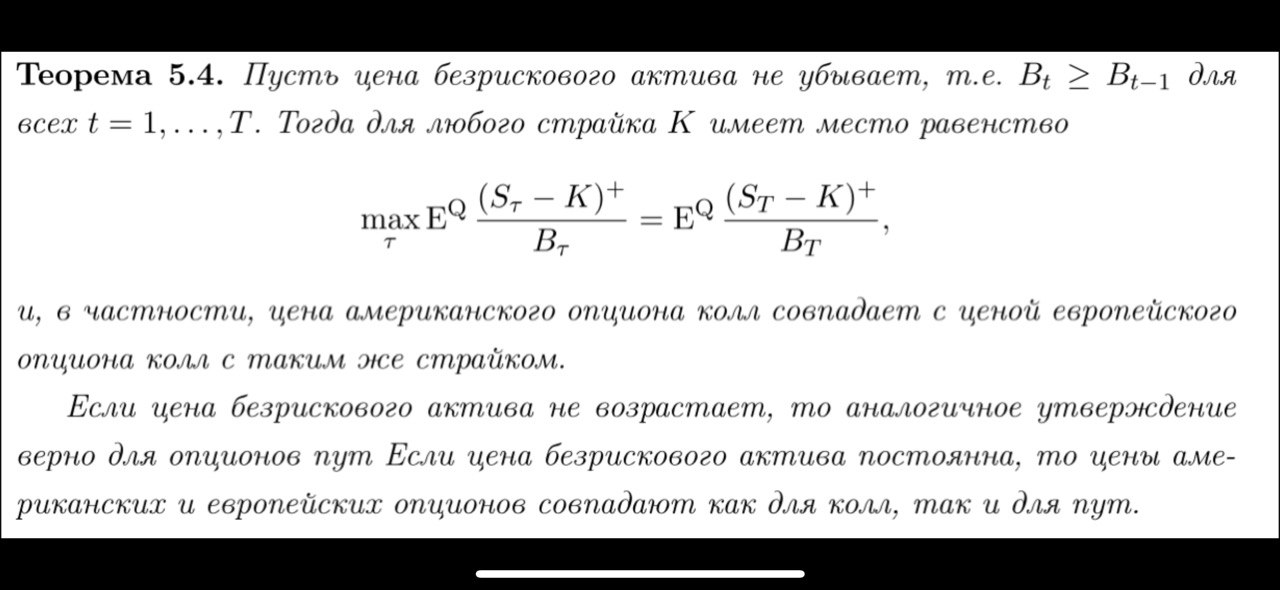

By the theorem above: 

$r = 0 \quad \Rightarrow \quad American_{call} = European_{call}, \quad American_{put} = European_{put}$

$r > 0 \quad \Rightarrow \quad American_{call} = European_{call}$

$r < 0 \quad \Rightarrow \quad American_{put} = European_{put}$

In [82]:
r_0= 0.00
european_call_0, european_put_0 = magic_interpolation(r_0)

+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
|              RESULTS, r = 0.0             | European CALL (K = 130.0%, sigma = 0.23398898531721918) | European PUT (K = 70.0%, sigma = 0.285) |
+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
| Price within a finite-differencing method |                    0.0174930789364085                   |           0.011941723387718624          |
|      Price from Black-Scholes formula     |                   0.01747121463796919                   |           0.011941761373729876          |
|                   error                   |                  2.186429843931137e-05                  |          3.7986011251420204e-08         |
+-------------------------------------------+---------------------------------------------------------+---------------------

In [83]:
r_plus = 0.20
european_call_plus, european_put_plus = magic_interpolation(r_plus)

+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
|              RESULTS, r = 0.2             | European CALL (K = 130.0%, sigma = 0.23398898531721918) | European PUT (K = 70.0%, sigma = 0.285) |
+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
| Price within a finite-differencing method |                   0.06730578678789523                   |          0.0020680196187961315          |
|      Price from Black-Scholes formula     |                   0.06733477522045739                   |          0.0020581702452906053          |
|                   error                   |                  2.8988432562160327e-05                 |           9.84937350552613e-06          |
+-------------------------------------------+---------------------------------------------------------+---------------------

In [84]:
r_minus = -0.20
european_call_minus, european_put_minus= magic_interpolation(r_minus)

+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
|             RESULTS, r = -0.2             | European CALL (K = 130.0%, sigma = 0.23398898531721918) | European PUT (K = 70.0%, sigma = 0.285) |
+-------------------------------------------+---------------------------------------------------------+-----------------------------------------+
| Price within a finite-differencing method |                  0.0026825275518941837                  |           0.047905608516896195          |
|      Price from Black-Scholes formula     |                   0.002654766106492363                  |           0.047938573194902245          |
|                   error                   |                  2.776144540182074e-05                  |          3.296467800605052e-05          |
+-------------------------------------------+---------------------------------------------------------+---------------------

To find the price of an american put option, we have to modify ```pde_solver``` slightly:
at each timestep compute $$max(S_t; (K-S_0e^{x+(r-\frac{\sigma^2}{2})(T-t)})e^{r(T-t)} ) $$
where $S_t$ -- price within a finite-differencing method

$(K-S_0e^{x+(r-\frac{\sigma^2}{2})(T-t)})e^{r(T-t)}$-- intrinsic value


In [85]:
from pricer_american import price_am, OptionType_am
from pde_solver_american import solve_1d_pde_am, FiniteDifferencingScheme_am

In [86]:
spot = S_0 
maturity = T  

In [87]:
number_of_time_steps = 301*4*4
finite_differencing_spacial_levels = 501*2*2
number_of_std_deviations = 4
scheme_type = FiniteDifferencingScheme_am.ImplicitAmericanPut

In [88]:
# Коэффициенты для PDE
pde_coefficients = lambda _: {"U": 0, "U_t": 1., "U_x": 0, "U_xx": 0.5 * sigma_put ** 2}

price_american_put_0 = price_am(
    maturity=maturity,
    strike=K_put,
    option_type=OptionType.PUT,
    number_of_spatial_levels=finite_differencing_spacial_levels,
    number_of_time_steps=number_of_time_steps,
    pde_coefficients=pde_coefficients,
    scheme=scheme_type,
    spot=spot,
    volatility=sigma_put,
    interest_rate=r_0,
)

price_american_put_plus = price_am(
    maturity=maturity,
    strike=K_put,
    option_type=OptionType.PUT,
    number_of_spatial_levels=finite_differencing_spacial_levels,
    number_of_time_steps=number_of_time_steps,
    pde_coefficients=pde_coefficients,
    scheme=scheme_type,
    spot=spot,
    volatility=sigma_put,
    interest_rate=r_plus,
)

price_american_put_minus = price_am(
    maturity=maturity,
    strike=K_put,
    option_type=OptionType.PUT,
    number_of_spatial_levels=finite_differencing_spacial_levels,
    number_of_time_steps=number_of_time_steps,
    pde_coefficients=pde_coefficients,
    scheme=scheme_type,
    spot=spot,
    volatility=sigma_put,
    interest_rate=r_minus,
)


In [89]:
eps = 1e-3
my_table = PrettyTable()
my_table.field_names = ["Check hypothesis", f"r = {r_0*100}%: European PUT = American PUT ", f"r = {r_plus*100}%: European PUT ? American PUT ", f"r = {r_minus*100}%: European PUT = American PUT "]
my_table.add_row(["European CALL", european_call_0, european_call_plus, european_call_minus])
my_table.add_row(["European PUT", european_put_0, european_put_plus, european_put_minus])
my_table.add_row(["American PUT", price_american_put_0, price_american_put_plus, price_american_put_minus])
my_table.add_row(["error",np.abs(european_put_0 - price_american_put_0), np.abs(european_put_plus- price_american_put_plus), np.abs(european_put_minus - price_american_put_minus)])
my_table.add_row([f"Are they equal?(error < {eps})", bool(np.abs(european_put_0 - price_american_put_0) < eps),bool(np.abs(european_put_plus- price_american_put_plus) < eps),bool(np.abs(european_put_minus - price_american_put_minus) < eps)])
print(my_table)

+--------------------------------+----------------------------------------+-----------------------------------------+------------------------------------------+
|        Check hypothesis        | r = 0.0%: European PUT = American PUT  | r = 20.0%: European PUT ? American PUT  | r = -20.0%: European PUT = American PUT  |
+--------------------------------+----------------------------------------+-----------------------------------------+------------------------------------------+
|         European CALL          |           0.0174930789364085           |           0.06730578678789523           |          0.0026825275518941837           |
|          European PUT          |          0.011941723387718624          |          0.0020680196187961315          |           0.047905608516896195           |
|          American PUT          |          0.012089509458408395          |           0.007502968112800633          |           0.04807409942901042            |
|             error              |